# 01 — BM25 Baseline on BEIR SciFact

End-to-end walkthrough: data loading → BM25 indexing → retrieval → TREC metric
evaluation → qualitative inspection.

Run this notebook first. The run file and metrics JSON it writes are consumed
by `04_analysis_and_figures.ipynb`.

In [1]:
import os, sys

# ── Auto-detect environment ───────────────────────────────────────────────────
try:
    import google.colab; _IN_COLAB = True
except ImportError:
    _IN_COLAB = False

_IN_KAGGLE = os.path.exists("/kaggle/working")

if _IN_COLAB or _IN_KAGGLE:
    # Remote: repo will be cloned in the next cell — update REPO_URL first.
    REPO_URL  = "https://github.com/YOUR_ORG/cs410-tech-review.git"  # ← REPLACE
    REPO_ROOT = "/content/cs410-tech-review" if _IN_COLAB else "/kaggle/working/cs410-tech-review"
else:
    # Local: locate the repo root relative to this notebook.
    _here = os.path.abspath(".")
    if os.path.basename(_here) == "notebooks" and os.path.isdir(os.path.join(_here, "..", "src")):
        REPO_ROOT = os.path.abspath(os.path.join(_here, ".."))
    elif os.path.isdir(os.path.join(_here, "src")):
        REPO_ROOT = _here
    else:
        REPO_ROOT = _here  # fallback: set manually if this prints the wrong path
    REPO_URL = None
    print(f"Local mode — REPO_ROOT: {REPO_ROOT}")

Local mode — REPO_ROOT: /home/kaiyul3/cs410-tech-review


In [2]:
# Clone repo (Colab / Kaggle only — skipped automatically in local mode).
if REPO_URL and not os.path.isdir(REPO_ROOT):
    !git clone {REPO_URL} {REPO_ROOT}
elif REPO_URL:
    print(f"Repo already present at {REPO_ROOT}")
else:
    print("Local mode — skipping clone.")

Local mode — skipping clone.


In [3]:
if _IN_COLAB or _IN_KAGGLE:
    %pip install -q \
        "torch>=2.1.0,<2.4.0" \
        "transformers==4.44.2" \
        "tokenizers<0.20" \
        "faiss-cpu>=1.7.4" \
        "ragatouille==0.0.9.post2" \
        "colbert-ai>=0.2.19" \
        "langchain==0.1.20" \
        "langchain-core==0.1.53" \
        "rank_bm25>=0.2.2" \
        "beir>=2.0.0" \
        "ranx>=0.3.16" \
        "scipy>=1.11.0" \
        "numpy>=1.24.0,<2.0.0" \
        "pandas>=2.0.0" \
        "pydantic>=2.0.0" \
        "matplotlib>=3.7.0" \
        "seaborn>=0.12.0" \
        "tqdm>=4.65.0" \
        "pyyaml>=6.0" \
        "ninja"
    print("Dependencies installed.")
else:
    # Local: colbert-review conda env already provides everything.
    # Inject the env's bin dir at the head of PATH so subprocesses the kernel
    # spawns (notably ColBERT's JIT C++ extension build via ninja) resolve the
    # right ninja/g++/nvcc, regardless of how the kernel was launched.
    import sys
    _env_bin = os.path.dirname(sys.executable)
    _path = os.environ.get("PATH", "")
    if _env_bin not in _path.split(os.pathsep):
        os.environ["PATH"] = _env_bin + os.pathsep + _path
    print(f"Local mode — using existing env at {_env_bin}")

Local mode — using existing env at /home/kaiyul3/.conda/envs/colbert-review/bin


In [4]:
import sys, os
from pathlib import Path

if REPO_ROOT not in sys.path:
    sys.path.insert(0, REPO_ROOT)

RUNS_DIR    = Path(REPO_ROOT) / "results" / "runs"
METRICS_DIR = Path(REPO_ROOT) / "results" / "metrics"
FIGURES_DIR = Path(REPO_ROOT) / "results" / "figures"
DATA_DIR    = Path(REPO_ROOT) / "data" / "raw"
for d in [RUNS_DIR, METRICS_DIR, FIGURES_DIR, DATA_DIR]:
    os.makedirs(d, exist_ok=True)

print("REPO_ROOT  :", REPO_ROOT)
print("RUNS_DIR   :", RUNS_DIR)
print("METRICS_DIR:", METRICS_DIR)

REPO_ROOT  : /home/kaiyul3/cs410-tech-review
RUNS_DIR   : /home/kaiyul3/cs410-tech-review/results/runs
METRICS_DIR: /home/kaiyul3/cs410-tech-review/results/metrics


In [5]:
import torch
if torch.cuda.is_available():
    device = "cuda"
    print(f"GPU: {torch.cuda.get_device_name(0)}")
else:
    device = "cpu"
    print("No GPU — CPU mode. BM25 is unaffected.")

GPU: NVIDIA A100-SXM4-80GB


## 1. Load SciFact

In [6]:
from src.data.load_scifact import load_scifact

# Downloads ~17 MB on first run; BEIR caches locally afterwards.
corpus = load_scifact(split="test", raw_dir=str(DATA_DIR))

print(f"docs    : {len(corpus.docs):,}")
print(f"queries : {len(corpus.queries):,}")
print(f"qrels   : {len(corpus.qrels):,}")

/home/kaiyul3/.conda/envs/colbert-review/lib/python3.10/site-packages/beir/util.py:11: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm
03:51:42 INFO  src.data.load_scifact — Loading scifact split=test from /home/kaiyul3/cs410-tech-review/data/raw/scifact
03:51:42 INFO  beir.datasets.data_loader — Loading Corpus...


  0%|          | 0/5183 [00:00<?, ?it/s]

03:51:42 INFO  beir.datasets.data_loader — Loaded 5183 TEST Documents.
03:51:42 INFO  beir.datasets.data_loader — Doc Example: {'text': 'Alterations of the architecture of cerebral white matter in the developing human brain can affect cortical development and result in functional disabilities. A line scan diffusion-weighted magnetic resonance imaging (MRI) sequence with diffusion tensor analysis was applied to measure the apparent diffusion coefficient, to calculate relative anisotropy, and to delineate three-dimensional fiber architecture in cerebral white matter in preterm (n = 17) and full-term infants (n = 7). To assess effects of prematurity on cerebral white matter development, early gestation preterm infants (n = 10) were studied a second time at term. In the central white matter the mean apparent diffusion coefficient at 28 wk was high, 1.8 microm2/ms, and decreased toward term to 1.2 microm2/ms. In the posterior limb of the internal capsule, the mean apparent diffusion coeffic

docs    : 5,183
queries : 300
qrels   : 339


## 2. Corpus inspection

In [7]:
import pandas as pd

doc_df = pd.DataFrame([
    {"doc_id": d.doc_id, "title": d.title[:80], "text_words": len(d.text.split())}
    for d in corpus.docs[:5]
])
print("=== Sample documents ===")
display(doc_df)

q_df = pd.DataFrame([{"qid": q.qid, "text": q.text} for q in corpus.queries[:5]])
print("\n=== Sample queries ===")
display(q_df)

=== Sample documents ===


,doc_id,title,text_words
0,4983,Microstructural development of human newborn c...,278
1,5836,Induction of myelodysplasia by myeloid-derived...,201
2,7912,"BC1 RNA, the transcript from a master gene for...",180
3,18670,The DNA Methylome of Human Peripheral Blood Mo...,238
4,19238,The human myelin basic protein gene is include...,241



=== Sample queries ===


,qid,text
0,1,0-dimensional biomaterials show inductive prop...
1,3,"1,000 genomes project enables mapping of genet..."
2,5,1/2000 in UK have abnormal PrP positivity.
3,13,5% of perinatal mortality is due to low birth ...
4,36,A deficiency of vitamin B12 increases blood le...


## 3. BM25 indexing

In [8]:
import time
from src.baselines.bm25 import BM25Config, BM25Retriever

cfg = BM25Config(k1=1.5, b=0.75, epsilon=0.25, lowercase=True,
                 remove_stopwords=True, min_token_len=2)
retriever = BM25Retriever(config=cfg)

t0 = time.perf_counter()
retriever.index(corpus.docs)
print(f"Index built in {time.perf_counter()-t0:.2f}s over {len(corpus.docs):,} docs.")

03:51:45 INFO  src.baselines.bm25 — Tokenizing 5183 documents for BM25 indexing.
03:51:45 INFO  src.baselines.bm25 — BM25 index built.


Index built in 0.62s over 5,183 docs.


## 4. Retrieve top-100 for all test queries

In [9]:
t0 = time.perf_counter()
bm25_rankings = retriever.search_all(corpus.queries, topk=100)
elapsed = time.perf_counter() - t0

total_hits = sum(len(v) for v in bm25_rankings.values())
print(f"{len(bm25_rankings):,} queries | {total_hits:,} hits | {elapsed:.2f}s")

300 queries | 30,000 hits | 3.25s


## 5. Qualitative hit inspection

In [10]:
doc_map = corpus.doc_map()
q_map   = corpus.query_map()

sample_qid = corpus.queries[0].qid
print(f"Query [{sample_qid}]: {q_map[sample_qid].text}\n")

for rank, (doc_id, score) in enumerate(bm25_rankings[sample_qid][:5], 1):
    doc = doc_map[doc_id]
    print(f"  Rank {rank} | doc_id={doc_id} | score={score:.4f}")
    print(f"    Title  : {doc.title[:90]}")
    print(f"    Snippet: {doc.text[:180]}...")
    print()

Query [1]: 0-dimensional biomaterials show inductive properties.

  Rank 1 | doc_id=40212412 | score=9.6992
    Title  : Periosteal bone formation--a neglected determinant of bone strength.
    Snippet: Life forms that have low body mass can hunt for food on the undersurface of branches or along shear cliff faces quite unperturbed by gravity. For larger animals, the hunt for dinne...

  Rank 2 | doc_id=43385013 | score=9.3602
    Title  : Epithelial and mesenchymal subpopulations within normal basal breast cell lines exhibit di
    Snippet: It has been proposed that epithelial-mesenchymal transition (EMT) in mammary epithelial cells and breast cancer cells generates stem cell features, and that the presence of EMT cha...

  Rank 3 | doc_id=10931595 | score=9.1136
    Title  : Geometry, epistasis, and developmental patterning.
    Snippet: Developmental signaling networks are composed of dozens of components whose interactions are very difficult to quantify in an embryo. Geometric reaso

## 6. Write TREC run file

In [11]:
from src.eval.metrics import write_run

run_path = RUNS_DIR / "bm25.trec"
n_lines = write_run(run_path, bm25_rankings, tag="bm25")
print(f"Wrote {n_lines:,} lines -> {run_path}")

03:51:49 INFO  src.eval.metrics — Wrote 30000 lines to /home/kaiyul3/cs410-tech-review/results/runs/bm25.trec


Wrote 30,000 lines -> /home/kaiyul3/cs410-tech-review/results/runs/bm25.trec


## 7. Evaluate — NDCG@10, MRR@10, MAP, Recall@100

In [12]:
from src.eval.metrics import evaluate_run, save_eval, DEFAULT_METRICS

qrels_map = corpus.qrels_map()

eval_result = evaluate_run(
    qrels_map=qrels_map,
    run=bm25_rankings,
    metrics=DEFAULT_METRICS,
    run_name="bm25",
)

print("=== BM25 aggregate metrics ===")
for metric, value in sorted(eval_result.metrics.items()):
    print(f"  {metric:<15}: {value:.4f}")

metrics_path = METRICS_DIR / "bm25.json"
save_eval(eval_result, metrics_path)
print(f"\nSaved -> {metrics_path}")

03:52:02 INFO  src.eval.metrics — Saved metrics to /home/kaiyul3/cs410-tech-review/results/metrics/bm25.json


=== BM25 aggregate metrics ===
  map            : 0.6251
  mrr@10         : 0.6317
  ndcg@10        : 0.6641
  recall@100     : 0.8759

Saved -> /home/kaiyul3/cs410-tech-review/results/metrics/bm25.json


## 8. Per-query NDCG@10 distribution

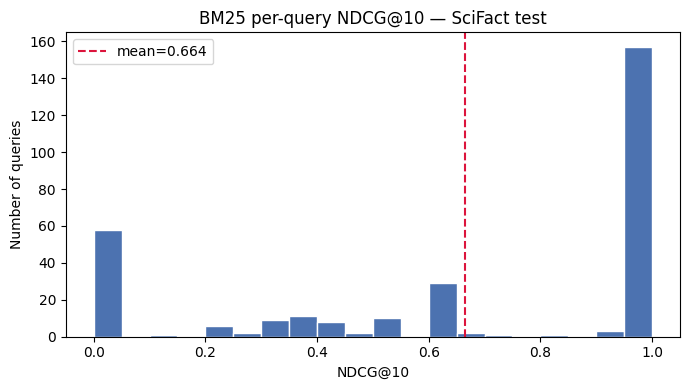

In [13]:
import matplotlib.pyplot as plt
import numpy as np

ndcg_vals = [v.get("ndcg@10", 0.0) for v in eval_result.per_query.values()]

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(ndcg_vals, bins=20, color="#4C72B0", edgecolor="white")
ax.axvline(np.mean(ndcg_vals), color="crimson", linestyle="--",
           label=f"mean={np.mean(ndcg_vals):.3f}")
ax.set_xlabel("NDCG@10")
ax.set_ylabel("Number of queries")
ax.set_title("BM25 per-query NDCG@10 — SciFact test")
ax.legend()
fig.tight_layout()
fig.savefig(FIGURES_DIR / "bm25_ndcg_hist.png", dpi=150, bbox_inches="tight")
plt.show()

## 9. Worst-performing queries

In [14]:
per_q_sorted = sorted(eval_result.per_query.items(),
                      key=lambda kv: kv[1].get("ndcg@10", 0.0))

print("=== 3 worst queries (NDCG@10) ===\n")
for qid, m in per_q_sorted[:3]:
    rel_docs  = set(qrels_map.get(qid, {}).keys())
    top10_ids = [d for d, _ in bm25_rankings.get(qid, [])[:10]]
    hit       = any(d in rel_docs for d in top10_ids)
    print(f"  [{qid}] ndcg@10={m.get('ndcg@10', 0):.3f}  relevant_in_top10={hit}")
    print(f"    Query: {q_map[qid].text}")
    print()

=== 3 worst queries (NDCG@10) ===

  [1] ndcg@10=0.000  relevant_in_top10=False
    Query: 0-dimensional biomaterials show inductive properties.

  [1049] ndcg@10=0.000  relevant_in_top10=False
    Query: Ribosomopathies have a low degree of cell and tissue specific pathology.

  [1088] ndcg@10=0.000  relevant_in_top10=False
    Query: Silencing of Bcl2 is important for the maintenance and progression of tumors.



## Summary

`results/runs/bm25.trec` and `results/metrics/bm25.json` are written.
Notebook 04 loads these for the final significance tests and report figures.